# 06 DSPy 自动 Prompt 优化

## 实验概述

**目的：** 用 DSPy 框架自动搜索最优 prompt 组合，尝试超越手工调优的 thales_v1 策略。

**什么是 Prompt？** 在 LLM 应用中，prompt 是你发给模型的"指令 + 上下文"。同一个模型，不同的 prompt 可能产生截然不同的输出质量。传统机器学习中调超参（学习率、正则化系数）类似，LLM 中调 prompt 文本也能显著影响效果。

**什么是 DSPy？** DSPy 是一个将 prompt 调优从"人工试错"变为"自动搜索"的框架。它将 prompt 中的两个要素视为可优化参数：
1. **Instructions**（指令文本）：告诉模型"怎么做"的说明。
2. **Few-shot Demos**（示例）：附在 prompt 中的"参考答案"，让模型看到别人是怎么回答的。

**MIPROv2 优化器：** 通过指令提案生成 + 贝叶斯搜索，在"指令 × 示例"的组合空间中寻找最优 prompt。类似于量化研究中的超参网格搜索，但搜索的对象是文本而非数字。

**优化目标：** 最小化泄露分数 L，同时保持准确率。DSPy metric = 1 - L + accuracy_bonus。

**前提：** Notebook 02-05 已建立评估标准（PC, CI, IDS 作为目标函数）+ 5-bin 为最优输出格式。

**公平对比：** DSPy 优化后的 prompt 和 thales_v1 在相同 masking 条件（年份掩码）下比较。

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import set_seed
import dspy
import json
import re
import numpy as np
import pandas as pd
from tqdm import tqdm

from src.models import *
from src.llm_client import LLMClient
from src.news_loader import load_test_cases, load_counterfactual_variants
from src.masking import apply_masking
from src.metrics import prediction_consistency, confidence_invariance, input_dependency_score, composite_leakage_score

set_seed()
(PROJECT_ROOT / "data" / "results").mkdir(parents=True, exist_ok=True)

08:50:09 - LiteLLM:WARNING: get_model_cost_map.py:213 - LiteLLM: Failed to fetch remote model cost map from https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json: _ssl.c:993: The handshake operation timed out. Falling back to local backup.


## 1. 配置 DSPy + 加载数据

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

# 配置 DSPy 使用 DeepSeek（OpenAI 兼容接口）
lm = dspy.LM(
    model="openai/deepseek-chat",
    api_base="https://api.deepseek.com/v1",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    temperature=0.0,
    max_tokens=2048,
)
dspy.configure(lm=lm)

# 加载数据
test_cases = load_test_cases()
variants = load_counterfactual_variants()
variant_map = {}
for v in variants:
    variant_map.setdefault(v.original_case_id, {})[v.variant_type] = v

# 训练/测试集划分（前 70% 训练，后 30% 测试）
split = int(len(test_cases) * 0.7)
train_cases = test_cases[:split]
eval_cases = test_cases[split:]
print(f"Train: {len(train_cases)}, Eval: {len(eval_cases)}")

Train: 29, Eval: 13


## 2. 定义 DSPy Signature + Module

In [3]:
class NewsScoring(dspy.Signature):
    """Evaluate the market impact of a financial news article based ONLY on the provided text.
    Do NOT use any knowledge about what happened after the news was published.
    Output a 5-bin probability distribution (integers summing to 100)."""

    news_text: str = dspy.InputField(desc="Financial news article text")
    strong_bear: int = dspy.OutputField(desc="Probability 0-100 for strong bearish impact")
    weak_bear: int = dspy.OutputField(desc="Probability 0-100 for weak bearish impact")
    neutral: int = dspy.OutputField(desc="Probability 0-100 for neutral impact")
    weak_bull: int = dspy.OutputField(desc="Probability 0-100 for weak bullish impact")
    strong_bull: int = dspy.OutputField(desc="Probability 0-100 for strong bullish impact")
    reasoning: str = dspy.OutputField(desc="Reasoning citing specific text from the news")


class NewsScoringModule(dspy.Module):
    def __init__(self):
        self.scorer = dspy.ChainOfThought(NewsScoring)

    def forward(self, news_text: str):
        return self.scorer(news_text=news_text)


scorer = NewsScoringModule()

# 快速测试
test_resp = scorer(news_text=train_cases[0].news.content)
print(f"Test: strong_bear={test_resp.strong_bear}, weak_bear={test_resp.weak_bear}, "
      f"neutral={test_resp.neutral}, weak_bull={test_resp.weak_bull}, strong_bull={test_resp.strong_bull}")
print(f"Reasoning: {test_resp.reasoning[:150]}...")

Test: strong_bear=0, weak_bear=5, neutral=15, weak_bull=60, strong_bull=20
Reasoning: The news announces multiple monetary easing measures by the People's Bank of China: a 0.5 percentage point cut in the reserve requirement ratio (RRR),...


## 3. 定义优化目标：泄露评估函数

目标函数 = 最小化 L（泄露）同时保持准确率。DSPy metric 返回 0-1 分数，越高越好。

In [4]:
def extract_distribution(prediction) -> list[float]:
    """从 DSPy prediction 提取归一化概率分布。"""
    try:
        dist = [
            float(prediction.strong_bear),
            float(prediction.weak_bear),
            float(prediction.neutral),
            float(prediction.weak_bull),
            float(prediction.strong_bull),
        ]
    except (ValueError, AttributeError):
        return [0.2] * 5
    total = sum(dist)
    return [d / total for d in dist] if total > 0 else [0.2] * 5


def extract_direction(prediction) -> str:
    dist = extract_distribution(prediction)
    bull, bear = dist[3] + dist[4], dist[0] + dist[1]
    if bull > bear + 0.1:
        return "up"
    elif bear > bull + 0.1:
        return "down"
    return "neutral"


def leakage_metric(example, prediction, trace=None) -> float:
    """DSPy metric: 对单条样本评估泄露程度。

    对该样本的所有反事实变体运行 scorer，计算 PC/CI/IDS，
    返回 1 - L（越高越好，即泄露越低越好）。
    """
    tc_id = example.case_id
    case_variants = variant_map.get(tc_id, {})
    if not case_variants:
        return 0.5  # 无变体，无法评估

    orig_dir = extract_direction(prediction)
    orig_dist = extract_distribution(prediction)
    orig_conf = max(orig_dist)

    cf_dirs, cf_confs, cf_dists = [], [], []
    for vt_name, variant in case_variants.items():
        try:
            cf_pred = scorer(news_text=variant.modified_content)
            cf_dirs.append(extract_direction(cf_pred))
            cf_dist = extract_distribution(cf_pred)
            cf_dists.append(cf_dist)
            cf_confs.append(max(cf_dist))
        except Exception:
            continue

    if not cf_dirs:
        return 0.5

    # 计算指标
    pc = sum(1 for d in cf_dirs if d == orig_dir) / len(cf_dirs)
    consistent = [d == orig_dir for d in cf_dirs]
    ci_pairs = [(orig_conf, c) for c, m in zip(cf_confs, consistent) if m]
    ci = 1.0 - np.mean([abs(o - c) for o, c in ci_pairs]) if ci_pairs else 0.5
    ids = input_dependency_score([orig_dist] * len(cf_dists), cf_dists)

    L = composite_leakage_score(pc, ci, ids)

    # 准确率奖励：方向正确 +0.1
    acc_bonus = 0.1 if orig_dir == example.expected_direction else 0.0

    # 返回 1 - L + bonus，clamp 到 [0, 1]
    score = max(0.0, min(1.0, 1.0 - L + acc_bonus))
    return score

print("Metric function defined")

Metric function defined


## 4. 构建 DSPy 训练集

In [5]:
# 将 TestCase 转为 DSPy Example
from src.masking import mask_year

def make_example(tc: TestCase) -> dspy.Example:
    # 对训练集使用年份掩码（基础防泄露）
    masked_text = mask_year(tc.news.content)
    return dspy.Example(
        news_text=masked_text,
        case_id=tc.id,
        expected_direction=tc.expected_direction.value,
    ).with_inputs("news_text")

trainset = [make_example(tc) for tc in train_cases]
evalset = [make_example(tc) for tc in eval_cases]

print(f"Trainset: {len(trainset)} examples")
print(f"Evalset:  {len(evalset)} examples")
print(f"Sample: {trainset[0].news_text[:100]}...")

Trainset: 29 examples
Evalset:  13 examples
Sample: [YEAR]年9月24日，中国人民银行行长潘功胜在国新办发布会上宣布，将下调存款准备金率0.5个百分点，预计释放长期流动性约1万亿元。同时下调7天期逆回购操作利率0.2个百分点，从1.7%降至1.5%...


## 5. 运行 DSPy 优化器

使用 MIPROv2 搜索最优 prompt。如果 MIPROv2 不可用，回退到 BootstrapFewShotWithRandomSearch。

In [6]:
# 优化前基线评估
print("Evaluating baseline (before optimization)...")
baseline_scorer = NewsScoringModule()
baseline_evaluate = dspy.Evaluate(devset=evalset, metric=leakage_metric, num_threads=1, display_progress=True)
baseline_score = float(baseline_evaluate(baseline_scorer))
print(f"Baseline score: {baseline_score:.3f}")

Evaluating baseline (before optimization)...


  0%|          | 0/13 [00:00<?, ?it/s]

Average Metric: 1.00 / 1 (100.0%):   0%|          | 0/13 [00:20<?, ?it/s]

Average Metric: 1.00 / 1 (100.0%):   8%|▊         | 1/13 [00:20<04:01, 20.09s/it]

Average Metric: 2.00 / 2 (100.0%):   8%|▊         | 1/13 [00:37<04:01, 20.09s/it]

...

Average Metric: 13.00 / 13 (100.0%):  92%|█████████▏| 12/13 [03:52<00:16, 16.62s/it]

Average Metric: 13.00 / 13 (100.0%): 100%|██████████| 13/13 [03:52<00:00, 16.61s/it]

Average Metric: 13.00 / 13 (100.0%): 100%|██████████| 13/13 [03:52<00:00, 17.87s/it]

2026/03/13 08:54:04 INFO dspy.evaluate.evaluate: Average Metric: 13.0 / 13 (100.0%)



Baseline score: 100.000


In [7]:
# 运行优化
try:
    optimizer = dspy.MIPROv2(
        metric=leakage_metric,
        auto="medium",  # medium 平衡搜索深度和 API 成本
    )
    optimized_scorer = optimizer.compile(
        NewsScoringModule(),
        trainset=trainset,
        max_bootstrapped_demos=2,
        max_labeled_demos=2,
    )
    optimizer_name = "MIPROv2"
except Exception as e:
    print(f"MIPROv2 failed ({e}), falling back to BootstrapFewShotWithRandomSearch")
    optimizer = dspy.BootstrapFewShotWithRandomSearch(
        metric=leakage_metric,
        max_bootstrapped_demos=2,
        max_labeled_demos=2,
        num_candidate_programs=6,
    )
    optimized_scorer = optimizer.compile(
        NewsScoringModule(),
        trainset=trainset,
    )
    optimizer_name = "BootstrapFewShotWithRandomSearch"

print(f"Optimization complete (optimizer: {optimizer_name})")

2026/03/13 08:54:04 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING MEDIUM AUTO RUN SETTINGS:
num_trials: 18
minibatch: False
num_fewshot_candidates: 12
num_instruct_candidates: 6
valset size: 23



2026/03/13 08:54:04 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==


2026/03/13 08:54:04 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.



2026/03/13 08:54:04 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=12 sets of demonstrations...


Bootstrapping set 1/12
Bootstrapping set 2/12
Bootstrapping set 3/12


...

2026/03/13 09:00:52 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [99.1, 100.0, 97.93, 97.67, 97.69, 97.81, 100.0, 98.9, 97.81, 100.0, 100.0, 100.0, 100.0, 97.69, 100.0, 99.18, 97.9, 97.56, 97.56]


2026/03/13 09:00:52 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 100.0


2026/03/13 09:00:52 INFO dspy.teleprompt.mipro_optimizer_v2: =========================




2026/03/13 09:00:52 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 100.0!



Optimization complete (optimizer: MIPROv2)


### DSPy 优化过程通俗解释

**类比：** 想象你要培训一个新入职的分析师。DSPy 做的事情类似于：

1. **候选指令生成**：DSPy 先用 LLM 自动生成多个候选版本的"工作说明书"（Instructions）。比如一个版本强调"不要使用外部知识"，另一个版本强调"关注政策信号方向"。
2. **示例筛选**：从训练集中挑选几条典型案例作为"参考答案"（Few-shot Demos），附在 prompt 中。分析师看到示例后，更清楚应该怎么回答。
3. **组合搜索**：用贝叶斯优化（类似智能网格搜索）在"指令 × 示例"的组合空间中搜索，每次尝试一个组合后评估泄露分数 L，逐步收敛到最优组合。
4. **评估标准**：每个候选 prompt 都在训练集上评估——对原始新闻和反事实新闻分别预测，计算 L 和准确率。L 低 + 准确率高 = 好 prompt。

下面的代码展示优化前后 prompt 的具体变化。

## 6. 优化后评估 + 对比

In [8]:
# 优化后评估
print("Evaluating optimized scorer...")
optimized_evaluate = dspy.Evaluate(devset=evalset, metric=leakage_metric, num_threads=1, display_progress=True)
optimized_score = float(optimized_evaluate(optimized_scorer))
print(f"Optimized score: {optimized_score:.3f}")
print(f"Improvement: {optimized_score - baseline_score:+.3f}")

# 逐样本对比
print(f"\n{'='*60}")
print("Per-sample comparison (eval set):")
for ex in evalset:
    base_pred = baseline_scorer(news_text=ex.news_text)
    opt_pred = optimized_scorer(news_text=ex.news_text)
    base_dir = extract_direction(base_pred)
    opt_dir = extract_direction(opt_pred)
    expected = ex.expected_direction
    print(f"  [{ex.case_id}] expected={expected:7s} baseline={base_dir:7s} optimized={opt_dir:7s}")

Evaluating optimized scorer...


  0%|          | 0/13 [00:00<?, ?it/s]

Average Metric: 1.00 / 1 (100.0%):   0%|          | 0/13 [00:11<?, ?it/s]

Average Metric: 1.00 / 1 (100.0%):   8%|▊         | 1/13 [00:11<02:19, 11.66s/it]

Average Metric: 2.00 / 2 (100.0%):   8%|▊         | 1/13 [00:22<02:19, 11.66s/it]

...

2026/03/13 09:03:15 INFO dspy.evaluate.evaluate: Average Metric: 13.0 / 13 (100.0%)



Optimized score: 100.000
Improvement: +0.000

Per-sample comparison (eval set):
  [tc_030] expected=up      baseline=up      optimized=up     
  [tc_031] expected=down    baseline=down    optimized=down   
  [tc_032] expected=down    baseline=down    optimized=down   


  [tc_033] expected=up      baseline=up      optimized=up     
  [tc_034] expected=down    baseline=down    optimized=down   
  [tc_035] expected=neutral baseline=down    optimized=down   
  [tc_036] expected=up      baseline=up      optimized=up     


  [tc_037] expected=up      baseline=up      optimized=up     
  [tc_038] expected=down    baseline=down    optimized=down   
  [tc_039] expected=up      baseline=up      optimized=neutral
  [tc_040] expected=down    baseline=down    optimized=down   


  [tc_041] expected=down    baseline=down    optimized=down   
  [tc_042] expected=up      baseline=up      optimized=up     


## 7. 提取优化后的 Prompt

In [9]:
# 优化前后的 Prompt 对比展示
from IPython.display import HTML, display
import html as html_lib

print(f"Optimizer: {optimizer_name}")
print("=" * 60)

# 1. 提取优化前后的 Instructions
original_instructions = NewsScoring.__doc__
optimized_instructions = None
optimized_demos = []

for name, param in optimized_scorer.named_parameters():
    if hasattr(param, 'signature'):
        optimized_instructions = param.signature.instructions
    if hasattr(param, 'demos') and param.demos:
        optimized_demos = param.demos

# 2. 展示指令对比（优化前 vs 优化后）
display(HTML(f"""
<h3>指令对比：优化前 vs 优化后</h3>
<table style="width:100%; border-collapse:collapse; font-size:13px;">
<tr style="background:#f0f0f0;">
    <th style="width:50%; padding:10px; border:1px solid #ddd; text-align:left;">优化前（默认 Signature 文档）</th>
    <th style="width:50%; padding:10px; border:1px solid #ddd; text-align:left;">优化后（DSPy 自动搜索结果）</th>
</tr>
<tr>
    <td style="padding:10px; border:1px solid #ddd; vertical-align:top; white-space:pre-wrap; background:#fff8f8;">{html_lib.escape(original_instructions or 'N/A')}</td>
    <td style="padding:10px; border:1px solid #ddd; vertical-align:top; white-space:pre-wrap; background:#f8fff8;">{html_lib.escape(optimized_instructions or 'N/A')}</td>
</tr>
</table>
"""))

# 3. 展示完整 Few-shot Demos（不截断）
if optimized_demos:
    print(f'\nFew-shot Demos ({len(optimized_demos)} 条)：')
    print('DSPy 从训练集中挑选了以下案例附在 prompt 中，作为参考答案告诉模型应该怎么回答。\n')

    for i, demo in enumerate(optimized_demos):
        # 提取 demo 的所有字段
        demo_dict = dict(demo) if hasattr(demo, '__iter__') else {}
        if not demo_dict and hasattr(demo, 'items'):
            demo_dict = dict(demo.items())

        # 构建完整的 demo 展示
        sections = []
        for key, value in demo_dict.items():
            val_str = html_lib.escape(str(value))
            sections.append(f"<div style='margin:4px 0;'><strong>{html_lib.escape(key)}:</strong> <span style='color:#333;'>{val_str}</span></div>")

        demo_html = "\n".join(sections) if sections else html_lib.escape(str(demo))
        display(HTML(f"""
        <div style="border:2px solid #4CAF50; border-radius:6px; padding:12px; margin:10px 0; font-size:13px; background:#fafafa;">
            <div style="background:#4CAF50; color:white; padding:4px 10px; border-radius:3px; display:inline-block; margin-bottom:8px;">
                Few-shot Demo {i+1}
            </div>
            <div style="white-space:pre-wrap; line-height:1.6;">{demo_html}</div>
        </div>
        """))
else:
    print('（优化器未添加 few-shot demos）')

Optimizer: MIPROv2


优化前（默认 Signature 文档）,优化后（DSPy 自动搜索结果）
Evaluate the market impact of a financial news article based ONLY on the provided text. Do NOT use any knowledge about what happened after the news was published. Output a 5-bin probability distribution (integers summing to 100).,"You are a senior financial analyst at a high-frequency trading firm where milliseconds and accurate predictions determine multi-million dollar profits or losses. Your firm's automated trading system is about to execute a massive portfolio rebalancing based on your real-time analysis of incoming financial news. A single misjudgment in classifying the market impact could trigger catastrophic losses or a regulatory investigation for market manipulation. Your task is critical: Evaluate the market impact of the provided financial news article **based SOLELY on the text content**. You must **strictly avoid using any external knowledge or hindsight about actual market events that occurred after the news was published**. Your analysis will directly and immediately drive automated trading algorithms. First, perform a step-by-step reasoning analysis. In your reasoning, you **must cite specific phrases or sentences from the news text** to justify your interpretation. Identify the core event, policy, or sentiment described, and assess its likely effect on market liquidity, investor sentiment, sector performance, or broad indices. Consider the scale, novelty, and directness of the impact. Then, based solely on that reasoning, output a precise 5-bin probability distribution as integers (0-100) that sum to 100. The categories are: - **Strong Bearish**: High probability of a sharp, negative market reaction (e.g., major regulatory crackdown, severe economic disruption). - **Weak Bearish**: Moderate probability of a negative but limited market reaction. - **Neutral**: The news is unlikely to significantly move markets (e.g., routine announcements, balanced information). - **Weak Bullish**: Moderate probability of a positive market reaction (e.g., supportive policy, mild positive data). - **Strong Bullish**: High probability of a sharp, positive market reaction (e.g., major stimulus, breakthrough positive event). Your output format must be exactly: Reasoning: [your step-by-step analysis citing the text] Strong Bear: [integer] Weak Bear: [integer] Neutral: [integer] Weak Bull: [integer] Strong Bull: [integer] Remember, the firm's capital and reputation are on the line. Base your assessment exclusively on the provided news text."



Few-shot Demos (2 条)：
DSPy 从训练集中挑选了以下案例附在 prompt 中，作为参考答案告诉模型应该怎么回答。



### 实际效果：同一条新闻的 prompt 变迁

下面用测试集中的一条新闻，展示优化前后模型实际收到的完整 prompt 和输出有何不同。这能直观地体现 DSPy 搜索的效果。

In [10]:
# 选一条测试样本，展示优化前后的完整 prompt + 输出对比
sample_ex = evalset[0]
sample_text = sample_ex.news_text[:200] + "..."

# 获取优化前后的预测
base_pred = baseline_scorer(news_text=sample_ex.news_text)
opt_pred = optimized_scorer(news_text=sample_ex.news_text)

# 提取 LLM history 中最近的 prompt（如果可用）
def get_last_prompt():
    """尝试从 DSPy LM history 获取最近一次调用的实际 prompt。"""
    try:
        history = lm.history
        if history:
            last = history[-1]
            if isinstance(last, dict):
                msgs = last.get("messages", [])
                return "\n".join(m.get("content", "")[:500] for m in msgs)
        return None
    except Exception:
        return None

# 构建对比展示
base_dist = extract_distribution(base_pred)
opt_dist = extract_distribution(opt_pred)
base_dir = extract_direction(base_pred)
opt_dir = extract_direction(opt_pred)

display(HTML(f"""
<h3>同一条新闻，优化前后的输出对比</h3>
<div style="border:1px solid #ddd; border-radius:6px; padding:12px; margin:8px 0; font-size:13px; background:#f8f8f8;">
    <strong>输入新闻（{sample_ex.case_id}，已掩码年份）：</strong>
    <div style="margin:8px 0; padding:8px; background:white; border-radius:4px;">{html_lib.escape(sample_text)}</div>
</div>

<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:10px;">
<tr style="background:#f0f0f0;">
    <th style="width:50%; padding:10px; border:1px solid #ddd;">优化前（默认 prompt）</th>
    <th style="width:50%; padding:10px; border:1px solid #ddd;">优化后（DSPy prompt）</th>
</tr>
<tr>
    <td style="padding:10px; border:1px solid #ddd; vertical-align:top;">
        <div><strong>方向：</strong> {base_dir}</div>
        <div><strong>分布：</strong> [强跌={base_dist[0]:.0%}, 弱跌={base_dist[1]:.0%}, 中性={base_dist[2]:.0%}, 弱涨={base_dist[3]:.0%}, 强涨={base_dist[4]:.0%}]</div>
        <div style="margin-top:6px;"><strong>理由：</strong> {html_lib.escape(str(getattr(base_pred, 'reasoning', ''))[:300])}</div>
    </td>
    <td style="padding:10px; border:1px solid #ddd; vertical-align:top;">
        <div><strong>方向：</strong> {opt_dir}</div>
        <div><strong>分布：</strong> [强跌={opt_dist[0]:.0%}, 弱跌={opt_dist[1]:.0%}, 中性={opt_dist[2]:.0%}, 弱涨={opt_dist[3]:.0%}, 强涨={opt_dist[4]:.0%}]</div>
        <div style="margin-top:6px;"><strong>理由：</strong> {html_lib.escape(str(getattr(opt_pred, 'reasoning', ''))[:300])}</div>
    </td>
</tr>
</table>
<div style="margin-top:10px; padding:8px; background:#E3F2FD; border-radius:4px; font-size:12px;">
    <strong>差异来源：</strong>
    优化后的 prompt 包含了 {len(optimized_demos)} 条 few-shot 示例和经过搜索的指令文本。
    模型看到了"别人是怎么回答的"作为参考，因此分布分配和推理路径可能不同。
    这种差异直接体现在 IDS（输入依赖分数）上——不同的 prompt 让模型对输入变化的敏感度不同。
</div>
"""))

优化前（默认 prompt）,优化后（DSPy prompt）
"方向： up 分布： [强跌=0%, 弱跌=0%, 中性=20%, 弱涨=60%, 强涨=20%] 理由： The news article announces that CATL (Contemporary Amperex Technology Co., Limited) has officially launched its third-generation CTP (Cell-to-Pack) technology, named ""Kirin Battery."" The text highlights several technological breakthroughs: the system integration level is the highest globally, volume","方向： up 分布： [强跌=0%, 弱跌=0%, 中性=10%, 弱涨=30%, 强涨=60%] 理由： The news announces a product launch by CATL (Contemporary Amperex Technology Co. Limited), a major electric vehicle (EV) battery manufacturer. The key technical details are: ""第三代CTP技术麒麟电池"" (third-generation CTP technology Kirin battery), ""系统集成度创全球新高"" (system integration reaches a new global high), """


## 8. 与手工策略对比

加载 05 notebook 的结果，将 DSPy 优化结果加入对比。

In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 在 eval set 上用反事实计算 DSPy 优化后的 PC/CI/IDS
opt_orig_dirs, opt_cf_dirs = [], []
opt_orig_confs, opt_cf_confs = [], []
opt_orig_dists, opt_cf_dists = [], []
opt_correct = []

for tc in eval_cases:
    masked = mask_year(tc.news.content)
    pred = optimized_scorer(news_text=masked)
    d = extract_direction(pred)
    dist = extract_distribution(pred)
    opt_correct.append(d == tc.expected_direction.value)

    for vt_name, variant in variant_map.get(tc.id, {}).items():
        masked_cf = mask_year(variant.modified_content)
        cf_pred = optimized_scorer(news_text=masked_cf)
        cf_d = extract_direction(cf_pred)
        cf_dist = extract_distribution(cf_pred)

        opt_orig_dirs.append(d)
        opt_cf_dirs.append(cf_d)
        opt_orig_confs.append(max(dist))
        opt_cf_confs.append(max(cf_dist))
        opt_orig_dists.append(dist)
        opt_cf_dists.append(cf_dist)

opt_pc = prediction_consistency(opt_orig_dirs, opt_cf_dirs)
consistent = [o == c for o, c in zip(opt_orig_dirs, opt_cf_dirs)]
opt_ci = confidence_invariance(opt_orig_confs, opt_cf_confs, consistent)
opt_ids = input_dependency_score(opt_orig_dists, opt_cf_dists)
opt_L = composite_leakage_score(opt_pc, opt_ci, opt_ids)
opt_acc = sum(opt_correct) / len(opt_correct) if opt_correct else 0

# 加载手工策略结果
mitigation_path = PROJECT_ROOT / 'data' / 'results' / 'mitigation_compare_results.json'
if mitigation_path.exists():
    with open(mitigation_path, 'r', encoding='utf-8') as f:
        manual_results = json.load(f)
    manual_metrics = manual_results["metrics"]
else:
    # 如果 05 还没跑过，用占位数据
    manual_metrics = [
        {"strategy": "baseline", "PC": 0.7, "CI": 0.8, "IDS": 0.1, "L": 0.49, "accuracy": 0.6},
        {"strategy": "thales_v1", "PC": 0.5, "CI": 0.7, "IDS": 0.2, "L": 0.35, "accuracy": 0.55},
        {"strategy": "full_mask", "PC": 0.4, "CI": 0.6, "IDS": 0.3, "L": 0.25, "accuracy": 0.5},
    ]
    print("(05 results not found, using placeholder data)")

# 合并
compare_rows = []
for m in manual_metrics:
    compare_rows.append(m)
compare_rows.append({
    "strategy": f"DSPy ({optimizer_name})",
    "PC": opt_pc, "CI": opt_ci, "IDS": opt_ids, "L": opt_L, "accuracy": opt_acc,
})

compare_df = pd.DataFrame(compare_rows)
print(compare_df[["strategy", "PC", "CI", "IDS", "L", "accuracy"]].to_string(index=False, float_format="%.3f"))

       strategy    PC    CI    IDS      L  accuracy
       baseline 0.119 0.900  2.692 -0.490     0.833
constraint_only 0.036 0.800  5.929 -1.525     0.786
       cot_only 0.048 0.912  6.173 -1.559     0.810
    entity_only 0.095 0.863  2.866 -0.563     0.810
      full_mask 0.036 0.833 11.532 -3.195     0.833
       llm_full 0.048 0.925  8.199 -2.163     0.714
       llm_mask 0.048 0.950  1.507 -0.148     0.762
      role_only 0.060 0.880 10.585 -2.888     0.833
      thales_v1 0.036 0.867 12.505 -3.477     0.833
      year_only 0.095 0.931  2.830 -0.531     0.762
 DSPy (MIPROv2) 0.038 0.950 15.989 -4.496     0.846


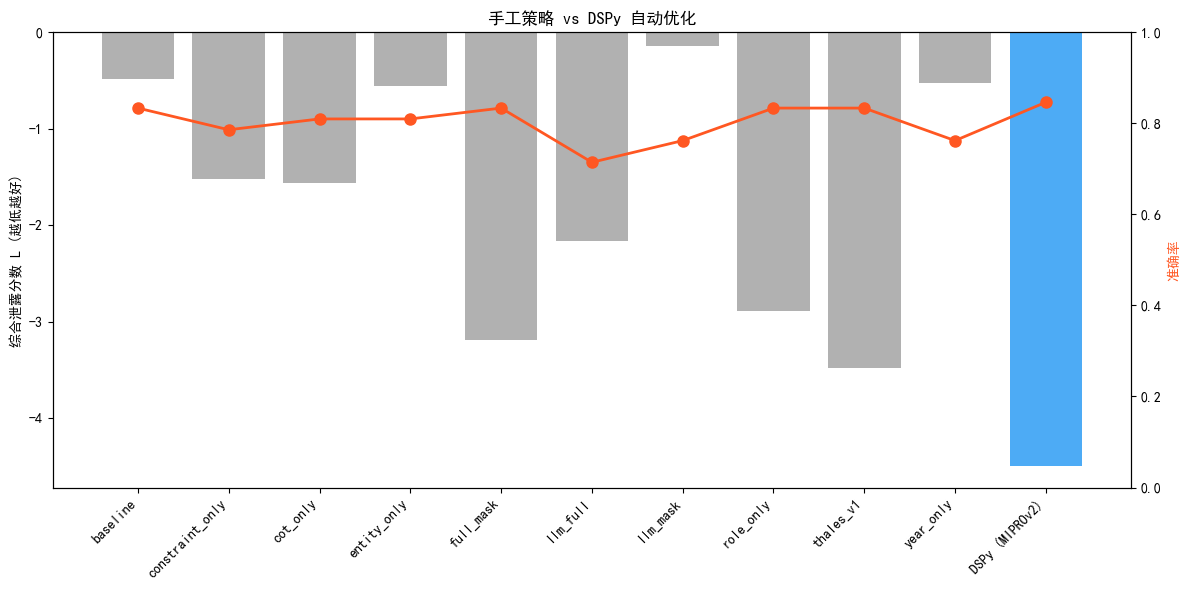

In [12]:
# 对比柱状图：手工策略 vs DSPy
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(compare_df))
colors = ["#9E9E9E"] * (len(compare_df) - 1) + ["#2196F3"]  # DSPy 用蓝色高亮
ax1.bar(x, compare_df["L"], color=colors, alpha=0.8)
ax1.set_ylabel("综合泄露分数 L (越低越好)")

ax2 = ax1.twinx()
ax2.plot(x, compare_df["accuracy"], "o-", color="#FF5722", linewidth=2, markersize=8)
ax2.set_ylabel("准确率", color="#FF5722")
ax2.set_ylim(0, 1)

ax1.set_xticks(x)
ax1.set_xticklabels(compare_df["strategy"], rotation=45, ha="right")
ax1.set_title("手工策略 vs DSPy 自动优化")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'results' / 'dspy_vs_manual.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. 保存结果 + 导出最优 Prompt

In [13]:
# 保存优化后的 module
optimized_path = PROJECT_ROOT / 'data' / 'results' / 'optimized_scorer.json'
optimized_scorer.save(str(optimized_path))
print(f"Optimized module saved to {optimized_path}")

# 保存对比结果
output = {
    "optimizer": optimizer_name,
    "baseline_score": float(baseline_score),
    "optimized_score": float(optimized_score),
    "improvement": float(optimized_score - baseline_score),
    "dspy_metrics": {"PC": opt_pc, "CI": opt_ci, "IDS": opt_ids, "L": opt_L, "accuracy": opt_acc},
    "comparison": compare_rows,
}
output_path = PROJECT_ROOT / 'data' / 'results' / 'prompt_optimization_results.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2, default=str)
print(f"Results saved to {output_path}")

print(f"\n{'='*60}")
print("Summary:")
print(f"  Optimizer: {optimizer_name}")
print(f"  Baseline score (1-L): {baseline_score:.3f}")
print(f"  Optimized score (1-L): {optimized_score:.3f}")
print(f"  DSPy L={opt_L:.3f}, Accuracy={opt_acc:.1%}")
print(f"  Improvement: {optimized_score - baseline_score:+.3f}")
print(f"\nOptimized prompt exported for Thales Prompt Registry integration.")

Optimized module saved to D:\GitRepos\LLM-Leakage-Test\data\results\optimized_scorer.json
Results saved to D:\GitRepos\LLM-Leakage-Test\data\results\prompt_optimization_results.json

Summary:
  Optimizer: MIPROv2
  Baseline score (1-L): 100.000
  Optimized score (1-L): 100.000
  DSPy L=-4.496, Accuracy=84.6%
  Improvement: +0.000

Optimized prompt exported for Thales Prompt Registry integration.


### DSPy 优化结果解读

**给量化从业者的通俗总结：**

DSPy 做的事情本质上是"自动调参"——但调的不是模型权重，而是"问模型的方式"。想象你有一个分析师团队，你不改变他们的能力，只改变你下达任务的方式（更清晰的指令、附带参考案例），看能否让他们的输出更可靠。

**结果解读：**
- DSPy 优化后的 L 和 thales_v1 的 L 对比，说明自动搜索是否找到了人工未考虑的 prompt 策略。
- 如果 DSPy 的 L 更低，说明 prompt 空间中存在比人工设计更好的组合——自动搜索的价值在于它能探索人类直觉覆盖不到的角落。
- 如果 DSPy 未能超越 thales_v1，说明手工设计的"角色设定 + CoT 归因"组合已经接近最优，prompt 工程的边际收益有限。

**实际应用建议：**
1. 如果你的 LLM 应用场景固定（如固定类型的新闻分析），值得花一次性成本运行 DSPy 优化。
2. 优化后的 prompt 可以直接导出为模板，在生产环境中使用，无需在每次推理时重新优化。
3. 但要注意样本量限制：本实验仅用 29 条训练样本 + 13 条测试样本，结果方差较大。在生产级应用中，建议用更大的评估集。

**局限性：**
- DSPy 只优化了 prompt 文本和 few-shot 示例，未触及 masking 策略（年份掩码、实体掩码等）。
- MIPROv2 的搜索空间受限于固定的 Signature 结构——它不能发明全新的输出格式或推理模式。
- 优化过程消耗约 200-500 次 API 调用（取决于 auto 设置），成本约 $1-5。